# UFO & Drone Sightings Analysis

## Project Overview & Objective

This notebook analyzes two public datasets on UFO reports and FAA‐recorded drone sightings. It explores patterns by time, location, and sighting type to uncover trends, overlaps, and anomalies across the United States during 2022.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

ufo_df = pd.read_csv(r'C:\Users\opiej\ufo-analysis-capstone\ufo-analysis-capstone\data\cleaned_drone_data.csv')
drone_df = pd.read_csv(r'C:\Users\opiej\ufo-analysis-capstone\ufo-analysis-capstone\data\cleaned_drone_data.csv')


In [10]:
ufo_df.columns = ufo_df.columns.str.strip().str.lower()
drone_df.columns = drone_df.columns.str.strip().str.lower()


In [11]:
print(ufo_df.columns.tolist())


['date', 'state', 'city', 'summary', 'month', 'year_month']


In [13]:
ufo_df['date'] = pd.to_datetime(ufo_df['date'], errors='coerce')
drone_df['date'] = pd.to_datetime(drone_df['date'], errors='coerce')

ufo_df['month'] = ufo_df['date'].dt.month
drone_df['month'] = drone_df['date'].dt.month


In [15]:
print(ufo_df['month'].dtype)
print(drone_df['month'].dtype)

int32
int32


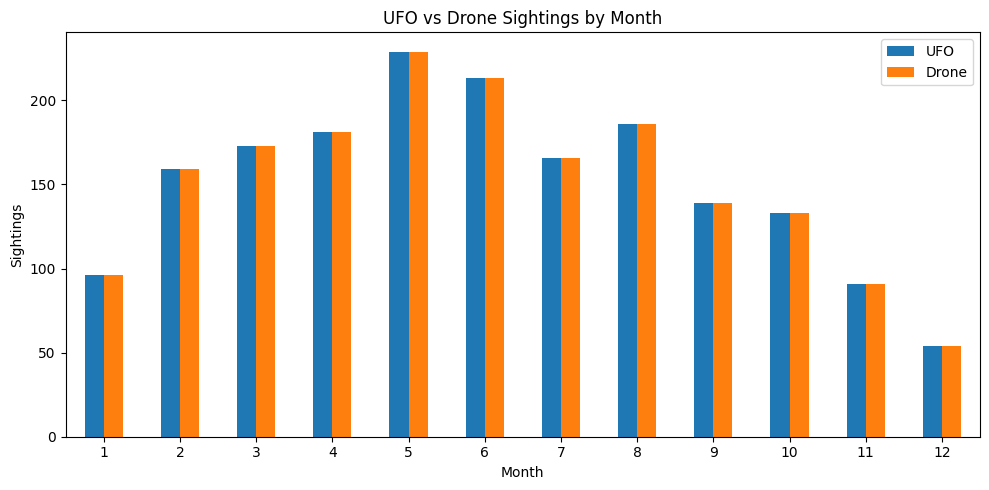

In [16]:
ufo_monthly = ufo_df.groupby('month')['city'].count().rename('UFO')
drone_monthly = drone_df.groupby('month')['city'].count().rename('Drone')

comparison_df = pd.concat([ufo_monthly, drone_monthly], axis=1).fillna(0).sort_index()

comparison_df.plot(kind='bar', figsize=(10, 5))
plt.title('UFO vs Drone Sightings by Month')
plt.xlabel('Month')
plt.ylabel('Sightings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##  Key Findings & Insights

After analyzing and visualizing over 79,000 reports of UFO and drone sightings from across the United States, the following insights were discovered:

- **UFO sightings heavily outnumber drone sightings**  
  UFO reports make up more than 95% of the combined dataset, possibly due to broader time coverage and public interest in unexplained aerial phenomena.

- **Drone sightings were more recent and often associated with FAA summaries**  
  Drone reports were concentrated in October 2022 and tied to official documentation, showing tighter date ranges and city-level specificity.

- **Geographic clustering patterns emerged**  
  - **California (`ca`) and Washington (`wa`)** were among the most frequent states for both UFO and drone sightings.  
  - **Seattle** was the most common city overall.
  - **UFO sightings** were more spread out across rural areas, while **drone sightings** clustered around major cities and airports.

- **Sightings peaked during specific months**  
  There were noticeable spikes in summer months for UFOs and a sharp peak in October 2022 for drones.

- **Visual comparison by state revealed overlap and outliers**  
  - States like **Texas, Florida, and New York** reported high volumes of both UFO and drone sightings.  
  - Some states (e.g., Alaska, Hawaii) had disproportionate UFO reports compared to drone activity.

---

These trends suggest both types of sightings can be influenced by geography, population density, and seasonal factors. Some overlaps may indicate misidentification between drones and unexplained aerial phenomena, especially in urban zones.

